# Aufgabe 6: vollständige Auswertung über 100 Spendersplits

Diese ausgeführte Berichtsfassung verwendet den unveränderten Modell-/Trainingscode aus `06e_cellcnn_quadratic_learnable_pooling.ipynb`. Alle Splits 0–99 werden ausgewertet. Dafür werden die lokal vorhandenen, passenden Modelle geladen; ein neues Benchmark-Training startet diese Fassung nicht. Die kleinen eingebauten Smoke-Tests bleiben aktiv.

# Aufgabe 6e: Quadratisches CellCNN mit lernbarem Pooling

Dieses Notebook ist eine Kopie von `06d_cellcnn_quadratic.ipynb`. Die einzige Architekturänderung ist **Hard-Top-1%-Mean → lernbares Soft-Top-Alpha-Mean**. Die quadratische Zellresponse bleibt:

\[
h_k(x)=\operatorname{ReLU}\left(b_k+w_k^\top x+\sum_j q_{kj}x_j^2\right).
\]

Die Eingaben sind dieselben ausschließlich anhand innerer Trainingsspender standardisierten `arcsinh(x/5)`-Markerwerte aus `gated_alive`. `quadratic_weights` starten exakt bei null. Damit entspricht zunächst die **Zellresponse** der linearen CellCNN-Baseline; die Bag-Scores unterscheiden sich bereits durch das weiche Pooling. Es gibt keine Kreuzterme, Prototypen, Distanzen oder Radien.

Standardmäßig werden zehn Splits **0–9** verwendet. Der separate Runner erweitert den Lauf auf **0–49**. Der Vergleich mit der linearen Baseline umfasst alle angeforderten Splits; die vorhandene Quadratic-Hard-Top-1%-Referenz umfasst ausschließlich **0–9**. Die lineare Task-4-Baseline wird zusätzlich aus ihren Artefakten rekonstruiert. Neue Ausgaben tragen ausschließlich den Präfix `task6_quadratic_learnable_`; bestehende Notebooks und Ergebnisse werden nicht überschrieben.


In [1]:
from pathlib import Path
import copy
import csv
import hashlib
import json
import os
import sys
import time
import warnings
from importlib.metadata import version

import flowkit as fk
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display

BONUS_SPLIT_IDS = list(range(100))
SPLIT_IDS = BONUS_SPLIT_IDS
GATE, RUN_MODE, GATE_SUFFIX = "gated_alive", "full", "_alive"
COFACTOR, TOP_FRACTION = 5.0, 0.01
LEARNING_RATE, L2_COEFFICIENT = 0.01, 1e-4
TRAINING_CELLS_PER_INPUT, TRAINING_INPUTS_PER_DONOR = 3000, 200
PREDICTION_CELLS_PER_INPUT, PREDICTION_INPUTS_PER_DONOR = 20000, 5
SCALER_CELLS_PER_DONOR = 20000
FILTER_COUNTS, BATCH_SIZE = [3, 4, 5], 128
MAX_EPOCHS, EARLY_STOPPING_PATIENCE = 100, 5
EVALUATION_CELLS_PER_DONOR, EVALUATION_SEED = 20000, 63000
EXPECTED_EVENT_COUNTS = {"gated_alive": 3438750}

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "NK_cell_dataset").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "NK_cell_dataset/NK_cell_dataset"
FCS_DIR = DATA_ROOT / "NK_cell_dataset" / GATE
LABELS_PATH, MARKERS_PATH = DATA_ROOT / "NK_fcs_samples_with_labels.csv", DATA_ROOT / "NK_markers.csv"
TABLES = PROJECT_ROOT / "results/tables"
SPLITS_PATH = TABLES / "task4_donor_splits.csv"
sys.path.insert(0, str(PROJECT_ROOT))
from src.task4_artifacts import make_run_config, file_digest, validate_prediction_splits, validate_parameter_table
from src.task5_interpretation import restore_scaler

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Gerät: {DEVICE}; PyTorch: {torch.__version__}; Bonus-Splits: {BONUS_SPLIT_IDS}")

# Vollständige Berichtsauswertung: dieselben bereits geprüften Modellartefakte.
os.environ["TASK6_RUN_TRAINING"] = "0"
os.environ["TASK6_SPLIT_LIMIT"] = "0"
os.environ["TASK6_HARD_TABLES"] = str(TABLES)


Gerät: cuda; PyTorch: 2.14.0+cu130; Bonus-Splits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


In [2]:
# Zweck: Alle Spenderdaten transformiert, aber weiterhin spenderweise getrennt laden.
with MARKERS_PATH.open(newline="", encoding="utf-8-sig") as stream:
    markers = next(csv.reader(stream))

label_table = pd.read_csv(LABELS_PATH)
label_table["donor_id"] = label_table["fcs_filename"].str.replace(
    r"_NK\.fcs$", "", regex=True
)
label_table["label"] = label_table["label"].astype(int)
fcs_paths = sorted(FCS_DIR.glob("*.fcs"))
fcs_table = pd.DataFrame(
    {
        "donor_id": [path.stem.removesuffix(GATE_SUFFIX) for path in fcs_paths],
        "fcs_path": fcs_paths,
    }
)
sample_table = (
    label_table[["donor_id", "label"]]
    .merge(fcs_table, on="donor_id", validate="one_to_one")
    .sort_values("donor_id")
    .reset_index(drop=True)
)
donor_splits = pd.read_csv(SPLITS_PATH)

assert len(markers) == 37
assert len(fcs_paths) == 20
assert len(sample_table) == 20
assert set(SPLIT_IDS).issubset(set(donor_splits["split_id"]))
split_labels = donor_splits[["donor_id", "label"]].drop_duplicates()
assert split_labels.merge(
    sample_table[["donor_id", "label"]],
    on=["donor_id", "label"],
    validate="one_to_one",
).shape[0] == len(sample_table)

def load_transformed_fcs(path: Path) -> np.ndarray:
    """Eine FCS-Datei read-only als ArcSinh-transformierte Markermatrix laden."""
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", message=r"FCS file .* reported incorrect data offset.*"
        )
        sample = fk.Sample(str(path), ignore_offset_error=True)
    frame = sample.as_dataframe(source="raw")
    short_names = pd.Index(sample.pns_labels, name="marker")
    if not short_names.is_unique:
        raise ValueError(f"Doppelte FCS-Kurznamen in {path.name}.")
    frame.columns = short_names
    missing = [marker for marker in markers if marker not in frame.columns]
    if missing:
        raise ValueError(f"Fehlende Marker in {path.name}: {missing}")
    values = frame.loc[:, markers].to_numpy(dtype=np.float32, copy=True)
    values = np.arcsinh(values / COFACTOR).astype(np.float32, copy=False)
    if not np.isfinite(values).all():
        raise ValueError(f"Nicht-endliche Werte in {path.name}.")
    return values

# Die getrennte Ablage verhindert ein versehentliches Aufteilen eines Spenders.
data_by_donor = {
    row.donor_id: load_transformed_fcs(row.fcs_path)
    for row in sample_table.itertuples(index=False)
}
label_by_donor = sample_table.set_index("donor_id")["label"].to_dict()
assert sum(map(len, data_by_donor.values())) == EXPECTED_EVENT_COUNTS[GATE]

display(
    pd.DataFrame(
        {
            "donor_id": list(data_by_donor),
            "label": [label_by_donor[x] for x in data_by_donor],
            "cells": [len(data_by_donor[x]) for x in data_by_donor],
        }
    )
)


,donor_id,label,cells
0,a_001,1,82324
1,a_002,1,108267
2,a_003,0,97529
3,a_004,0,140687
4,a_005,1,155335
5,a_006,0,90075
6,a_007,1,104805
7,a_009,0,216632
8,a_010,0,122209
9,a_011,0,258461


In [3]:
# Referenzcode und Eingabedaten prüfen, ohne 04c auszuführen oder Artefakte zu schreiben.
baseline_path = TABLES / "task4_cellcnn_predictions_gated_alive_full.csv"
baseline_config_path = baseline_path.with_suffix(".config.json")
baseline_config = json.loads(baseline_config_path.read_text())
expected_parameters = {
    "method": "cellcnn", "gate": GATE, "run_mode": RUN_MODE,
    "cofactor": COFACTOR, "learning_rate": LEARNING_RATE,
    "l2_coefficient": L2_COEFFICIENT, "top_fraction": TOP_FRACTION,
    "training_cells_per_input": TRAINING_CELLS_PER_INPUT,
    "training_inputs_per_donor": TRAINING_INPUTS_PER_DONOR,
    "prediction_cells_per_input": PREDICTION_CELLS_PER_INPUT,
    "prediction_inputs_per_donor": PREDICTION_INPUTS_PER_DONOR,
    "scaler_cells_per_donor": SCALER_CELLS_PER_DONOR,
    "filter_counts": FILTER_COUNTS, "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS, "patience": EARLY_STOPPING_PATIENCE,
    "threshold": 0.5, "implementation_version": "pytorch_materialized_v1",
    "model_format": "complete_filter_parameters_v1",
}
expected_config = make_run_config(
    baseline_config["parameters"] | expected_parameters,
    [SPLITS_PATH, LABELS_PATH, MARKERS_PATH, *fcs_paths],
    PROJECT_ROOT / "notebooks/04c_cellcnn.ipynb", [4, 6, 8, 10],
)
if baseline_config != expected_config:
    raise ValueError("Baseline-Konfiguration, Referenzcode oder Eingangsdaten passen nicht.")

baseline_predictions = pd.read_csv(baseline_path, float_precision="round_trip")
baseline_filters_path = TABLES / "task4_cellcnn_filters_gated_alive_full.csv"
baseline_filters = pd.read_csv(baseline_filters_path, float_precision="round_trip")
baseline_selection = pd.read_csv(TABLES / "task4_cellcnn_selection_gated_alive_full.csv")
baseline_predictions = baseline_predictions.loc[baseline_predictions.split_id.isin(BONUS_SPLIT_IDS)].copy()
baseline_filters = baseline_filters.loc[baseline_filters.split_id.isin(BONUS_SPLIT_IDS)].copy()
validate_prediction_splits(baseline_predictions, donor_splits)
validate_parameter_table(baseline_filters, baseline_predictions, markers, ["split_id", "filter_id"],
    ["filter_weight", "filter_bias", "output_weight_0", "output_weight_1",
     "output_bias_0", "output_bias_1", "output_weight_contrast", "scaler_mean", "scaler_scale"])
assert set(baseline_predictions.split_id) == set(BONUS_SPLIT_IDS)
for split_id in BONUS_SPLIT_IDS:
    split = donor_splits.loc[donor_splits.split_id.eq(split_id)]
    assert len(split) == 20 and split.donor_id.nunique() == 20
    assert split.outer_partition.eq("test").sum() == 6
    assert split.outer_partition.eq("train").sum() == 14
    assert set(split.loc[split.outer_partition.eq("train"), "inner_fold"]) == {0, 1, 2}
    selection = baseline_selection.loc[baseline_selection.split_id.eq(split_id)]
    assert len(selection) == 9
    assert set(zip(selection.inner_fold, selection.filter_count)) == {(f, k) for f in range(3) for k in FILTER_COUNTS}
    best = selection.sort_values(
        ["validation_accuracy", "validation_roc_auc", "best_validation_loss", "filter_count", "inner_fold"],
        ascending=[False, False, True, True, True]).iloc[0]
    assert selection.selected.sum() == 1 and bool(best.selected)
    filters = baseline_filters.loc[baseline_filters.split_id.eq(split_id)]
    pred = baseline_predictions.loc[baseline_predictions.split_id.eq(split_id)]
    assert filters.inner_fold.eq(best.inner_fold).all() and pred.selected_inner_fold.eq(best.inner_fold).all()
    assert filters.filter_id.nunique() == best.filter_count and pred.filter_count.eq(best.filter_count).all()
    assert np.allclose(filters.output_weight_contrast, filters.output_weight_1 - filters.output_weight_0)
    assert filters.scaler_scale.gt(0).all()
    for frame in [filters, pred]:
        assert frame.gate.eq(GATE).all() and frame.run_mode.eq(RUN_MODE).all()
        assert frame.top_fraction.eq(TOP_FRACTION).all()
    assert pred.score.between(0, 1).all()

# Identische Originalereignisse je Spender, unabhängig von Modell und Split.
evaluation_indices = {
    donor: np.random.default_rng(EVALUATION_SEED + i).choice(
        len(data_by_donor[donor]), min(EVALUATION_CELLS_PER_DONOR, len(data_by_donor[donor])), replace=False)
    for i, donor in enumerate(sorted(data_by_donor))
}
evaluation_config = {
    "baseline_config": baseline_config,
    "baseline_predictions_sha256": file_digest(baseline_path),
    "baseline_filters_sha256": file_digest(baseline_filters_path),
    "split_ids": BONUS_SPLIT_IDS, "evaluation_seed": EVALUATION_SEED,
    "evaluation_cells_per_donor": EVALUATION_CELLS_PER_DONOR,
    "selection": "largest_positive_output_contrast", "baseline_membership": "half_inner_training_maximum",
    "halfmax_zero_rule": "strict_response_greater_than_half_maximum",
    "event_indices_sha256": hashlib.sha256(b"".join(
        evaluation_indices[d].astype("<i8").tobytes() for d in sorted(evaluation_indices))).hexdigest(),
}
print("Baseline-Artefakte, Referenzcode und spenderweise Splits geprüft.")


Baseline-Artefakte, Referenzcode und spenderweise Splits geprüft.


## Modell und unverändertes Trainingsverfahren

Sampling, Trainings-Scaler, Adam, Lernrate, Baggrößen, L2-Koeffizient, maximal 100 Epochen und Early Stopping bleiben wie in 06d. Pro Outer-Split werden drei innere Folds und die Filterzahlen 3, 4 und 5 verglichen. Die Auswahl erfolgt nach Validierungsgenauigkeit, Validierungs-AUC, Verlust und denselben Tie-Breakern. Das ausgewählte innere Modell wird direkt getestet, ohne Refit auf allen äußeren Trainingsspendern.

Die linearen Filter und der Output-Layer werden in derselben Reihenfolge wie in 06d initialisiert. Die Nullinitialisierung von `quadratic_weights` und die konstante Initialisierung von `raw_alpha` verbrauchen keine Zufallszahlen. Die Regularisierung bleibt
\(\lambda(\lVert W\rVert^2+\lVert Q\rVert^2+\lVert V\rVert^2)\); Biases und Alpha erhalten keine zusätzliche Strafe.

Die Pooling-Methoden stammen direkt aus `GrHa-learnable-pooling` (Quellstand `1941243`), ohne dessen Prototype-Modell oder Geometriestrafe. Pro Filter gilt
\[
\alpha_k=\sigma(\theta_k),\quad \theta_k^{(0)}=\operatorname{logit}(0.01),\quad \tau=0.002.
\]
Für die absteigend sortierten **Quadratic-ReLU-Responses** \(s_{(r)k}\), \(r=1,\ldots,N\), gilt
\[
m_{rk}=\sigma\!\left(\frac{\alpha_k-(r-\frac12)/N}{\tau}\right),\qquad
P_k=\frac{\sum_r m_{rk}s_{(r)k}}{\max(\sum_r m_{rk},10^{-6})}.
\]
Das Netz liefert lineare Output-Logits aus \(P\); Softmax wird wie bisher für die Vorhersage angewendet. Alpha wird gelernt, die Temperatur bleibt fest. Diese Erweiterung ist ein Experiment zusätzlich zur CellCNN-Baseline, ohne neue Hyperparametersuche.


In [4]:
EPS = 1e-6
INITIAL_ALPHA = 0.01
POOLING_TEMPERATURE = 0.002
IMPLEMENTATION_VERSION = "quadratic_relu_soft_top_fraction_v1"


class QuadraticCellCNN(nn.Module):
    """Quadratische ReLU-Filter mit lernbarem weichem Top-Fraction-Pooling."""
    def __init__(self, marker_count, filter_count, initial_alpha=INITIAL_ALPHA):
        super().__init__()
        self.cell_filters = nn.Linear(marker_count, filter_count)
        self.output_layer = nn.Linear(filter_count, 2)
        self.quadratic_weights = nn.Parameter(torch.zeros(filter_count, marker_count))
        self.raw_alpha = nn.Parameter(torch.full(
            (filter_count,), float(np.log(initial_alpha / (1 - initial_alpha)))))

    def responses(self, values):
        linear = self.cell_filters(values)
        quadratic = nn.functional.linear(values.square(), self.quadratic_weights)
        return torch.relu(linear + quadratic)

    def pooling_fractions(self):
        return torch.sigmoid(self.raw_alpha)

    def pooled_responses(self, values):
        responses = self.responses(values)  # [B, N, K]
        sorted_responses = torch.sort(responses, dim=1, descending=True).values
        n_cells = responses.shape[1]
        q = (torch.arange(n_cells, device=responses.device, dtype=responses.dtype) + 0.5) / n_cells
        alpha = self.pooling_fractions()
        mask = torch.sigmoid((alpha.view(1, 1, -1) - q.view(1, -1, 1)) / POOLING_TEMPERATURE)
        return (mask * sorted_responses).sum(dim=1) / mask.sum(dim=1).clamp_min(EPS)

    def forward(self, values):
        return self.output_layer(self.pooled_responses(values))


In [5]:
# Zweck: Spenderbalancierte Multi-Cell-Inputs erzeugen und die CellCNN-Schichten definieren.
def materialize_multicell_inputs(
    donor_ids: list[str],
    scaled_data: dict[str, np.ndarray],
    cells_per_input: int,
    inputs_per_donor: int,
    seed: int,
) -> TensorDataset:
    """Feste zufällige Zellgruppen mit je einem Spenderlabel materialisieren.

    Jeder Spender erzeugt gleich viele Inputs. Ziehen mit Zurücklegen erhöht
    die Zahl der Trainingsbeispiele, ohne Spender als unabhängig zu vervielfachen.
    """
    donor_ids = sorted(donor_ids)
    input_count = len(donor_ids) * inputs_per_donor
    values = np.empty(
        (input_count, cells_per_input, len(markers)), dtype=np.float32
    )
    labels = np.empty(input_count, dtype=np.int64)
    input_index = 0
    for donor_id in donor_ids:
        donor_values = scaled_data[donor_id]
        for _ in range(inputs_per_donor):
            # Ein eigener deterministischer Teilseed macht jeden Input reproduzierbar.
            rng = np.random.default_rng(seed + input_index)
            cell_indices = rng.integers(
                0, len(donor_values), size=cells_per_input
            )
            values[input_index] = donor_values[cell_indices]
            labels[input_index] = label_by_donor[donor_id]
            input_index += 1
    return TensorDataset(
        torch.from_numpy(values).to(DEVICE),
        torch.from_numpy(labels).to(DEVICE),
    )


def fit_balanced_scaler(donor_ids: list[str], cells_per_donor: int, seed: int):
    """Scaler auf gleich vielen Zellen je Trainingsspender fitten."""
    rng = np.random.default_rng(seed)
    scaler_parts = []
    for donor_id in sorted(donor_ids):
        values = data_by_donor[donor_id]
        if len(values) < cells_per_donor:
            raise ValueError(f"Zu wenige Zellen für Skalierung: {donor_id}")
        indices = rng.choice(len(values), size=cells_per_donor, replace=False)
        scaler_parts.append(values[indices])
    scaler = StandardScaler().fit(np.concatenate(scaler_parts))
    return scaler


def scale_donors(donor_ids: list[str], scaler: StandardScaler):
    """Bereits gefittete Trainingsparameter unverändert auf Spender anwenden."""
    return {
        donor_id: scaler.transform(data_by_donor[donor_id]).astype(np.float32, copy=False)
        for donor_id in donor_ids
    }


In [6]:
# Zweck: Modellkandidaten mit L2-Regularisierung und validierungsbasiertem Stopp trainieren.
def regularized_loss(model: QuadraticCellCNN, logits: torch.Tensor, labels: torch.Tensor):
    """Kreuzentropie plus L2-Strafe der lernbaren Gewichtsmatrizen berechnen."""
    cross_entropy = nn.functional.cross_entropy(logits, labels)
    weight_penalty = (
        model.cell_filters.weight.square().sum()
        + model.quadratic_weights.square().sum()
        + model.output_layer.weight.square().sum()
    )
    return cross_entropy + L2_COEFFICIENT * weight_penalty


def evaluate_loader(model: QuadraticCellCNN, loader: DataLoader) -> float:
    """Mittleren regularisierten Verlust ohne Gradienten berechnen."""
    model.eval()
    weighted_loss_sum = 0.0
    example_count = 0
    with torch.no_grad():
        for values, labels in loader:
            logits = model(values.to(DEVICE))
            batch_loss = float(regularized_loss(model, logits, labels.to(DEVICE)))
            weighted_loss_sum += batch_loss * len(labels)
            example_count += len(labels)
    return weighted_loss_sum / example_count


def train_candidate(
    train_ids: list[str],
    validation_ids: list[str],
    filter_count: int,
    seed: int,
) -> tuple[QuadraticCellCNN, StandardScaler, dict[str, object]]:
    """Einen Kandidaten ausschließlich auf innerem Training und Validierung fitten.

    Zurückgegeben werden der beste Modellzustand, sein Trainings-Scaler und
    die Lernhistorie; äußere Testspender werden hier nie verwendet.
    """
    torch.manual_seed(seed)
    scaler = fit_balanced_scaler(train_ids, SCALER_CELLS_PER_DONOR, seed)
    scaled_data = scale_donors(train_ids + validation_ids, scaler)
    train_dataset = materialize_multicell_inputs(
        train_ids, scaled_data, TRAINING_CELLS_PER_INPUT,
        TRAINING_INPUTS_PER_DONOR, seed + 1_000,
    )
    validation_dataset = materialize_multicell_inputs(
        validation_ids, scaled_data, TRAINING_CELLS_PER_INPUT,
        TRAINING_INPUTS_PER_DONOR, seed + 2_000,
    )
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, generator=generator,
    )
    validation_loader = DataLoader(
        validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    model = QuadraticCellCNN(len(markers), filter_count, INITIAL_ALPHA).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_state = copy.deepcopy(model.state_dict())
    best_validation_loss = np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(MAX_EPOCHS):
        model.train()
        train_losses = []
        for values, labels in train_loader:
            optimizer.zero_grad()
            logits = model(values.to(DEVICE))
            loss = regularized_loss(model, logits, labels.to(DEVICE))
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach()))

        validation_loss = evaluate_loader(model, validation_loader)
        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": float(np.mean(train_losses)),
                "validation_loss": validation_loss,
            }
        )
        # Nur echte Verbesserungen ersetzen den gesicherten besten Zustand.
        if validation_loss < best_validation_loss - 1e-6:
            best_validation_loss = validation_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                break

    model.load_state_dict(best_state)
    training_info = {
        "epochs_run": len(history),
        "best_validation_loss": best_validation_loss,
        "history": history,
    }
    return model, scaler, training_info


In [7]:
# Zweck: Kandidaten spenderweise bewerten, auswählen und ihre Filter für Aufgabe 5 sichern.
def predict_donor(
    model: QuadraticCellCNN,
    scaler: StandardScaler,
    donor_id: str,
    seed: int,
) -> float:
    """Mehrere zufällige Multi-Cell-Vorhersagen eines Spenders mitteln."""
    values = data_by_donor[donor_id]
    input_cell_count = min(PREDICTION_CELLS_PER_INPUT, len(values))
    rng = np.random.default_rng(seed)
    probabilities = []
    model.eval()
    with torch.no_grad():
        for _ in range(PREDICTION_INPUTS_PER_DONOR):
            indices = rng.choice(len(values), size=input_cell_count, replace=False)
            scaled = scaler.transform(values[indices]).astype(np.float32, copy=False)
            logits = model(torch.from_numpy(scaled).unsqueeze(0).to(DEVICE))
            probability = torch.softmax(logits, dim=1)[0, 1].item()
            probabilities.append(probability)
    return float(np.mean(probabilities))


def train_outer_split(split_id: int):
    """Alle inneren Kandidaten fitten und genau ein Modell extern testen.

    Die Funktion liefert getrennte Tabellen für Testvorhersagen, Auswahlprozess
    und interpretierbare Filterparameter des ausgewählten Netzes.
    """
    split = donor_splits.loc[donor_splits["split_id"] == split_id]
    split_seed = int(split["split_seed"].iloc[0])
    test_ids = split.loc[split["outer_partition"] == "test", "donor_id"].tolist()
    candidates = []
    selection_records = []

    for inner_fold in range(3):
        train_ids = split.loc[
            (split["outer_partition"] == "train")
            & (split["inner_fold"] != inner_fold), "donor_id"
        ].tolist()
        validation_ids = split.loc[
            (split["outer_partition"] == "train")
            & (split["inner_fold"] == inner_fold), "donor_id"
        ].tolist()
        assert not set(train_ids) & set(validation_ids)
        assert not set(train_ids + validation_ids) & set(test_ids)

        for filter_count in FILTER_COUNTS:
            candidate_seed = split_seed + 10_000 * inner_fold + 100 * filter_count
            model, scaler, training_info = train_candidate(
                train_ids, validation_ids, filter_count, candidate_seed
            )
            validation_scores = np.array(
                [
                    predict_donor(model, scaler, donor_id, candidate_seed + 50_000 + index)
                    for index, donor_id in enumerate(sorted(validation_ids))
                ]
            )
            validation_true = np.array(
                [label_by_donor[x] for x in sorted(validation_ids)]
            )
            validation_accuracy = float(
                ((validation_scores >= 0.5).astype(int) == validation_true).mean()
            )
            validation_auc = float(roc_auc_score(validation_true, validation_scores))
            record = {
                "split_id": split_id,
                "gate": GATE,
                "run_mode": RUN_MODE,
                "device": DEVICE.type,
                "implementation_version": IMPLEMENTATION_VERSION,
                "inner_fold": inner_fold,
                "filter_count": filter_count,
                "candidate_seed": candidate_seed,
                "validation_accuracy": validation_accuracy,
                "validation_roc_auc": validation_auc,
                "best_validation_loss": training_info["best_validation_loss"],
                "epochs_run": training_info["epochs_run"],
            }
            selection_records.append(record)
            candidates.append({"model": model, "scaler": scaler, **record})
            print(f"  Fold {inner_fold}, Filter {filter_count}: {training_info['epochs_run']} Epochen", flush=True)

    # Sortierschlüssel kodiert die vorab festgelegte Auswahl samt Tie-Breakern.
    candidates.sort(
        key=lambda item: (
            -item["validation_accuracy"],
            -item["validation_roc_auc"],
            item["best_validation_loss"],
            item["filter_count"],
            item["inner_fold"],
        )
    )
    selected = candidates[0]
    for record in selection_records:
        record["selected"] = (
            record["inner_fold"] == selected["inner_fold"]
            and record["filter_count"] == selected["filter_count"]
        )

    prediction_records = []
    for index, donor_id in enumerate(sorted(test_ids)):
        score = predict_donor(
            selected["model"], selected["scaler"], donor_id,
            split_seed + 900_000 + index,
        )
        prediction_records.append(
            {
                "method": "cellcnn_quadratic_learnable",
                "gate": GATE,
                "run_mode": RUN_MODE,
                "device": DEVICE.type,
                "implementation_version": IMPLEMENTATION_VERSION,
                "split_id": split_id,
                "split_seed": split_seed,
                "donor_id": donor_id,
                "y_true": label_by_donor[donor_id],
                "score": score,
                "decision_threshold": 0.5,
                "y_pred": int(score >= 0.5),
                "filter_count": selected["filter_count"],
                "selected_inner_fold": selected["inner_fold"],
                "training_cells_per_input": TRAINING_CELLS_PER_INPUT,
                "training_inputs_per_donor": TRAINING_INPUTS_PER_DONOR,
                "prediction_cells_per_input": min(
                    PREDICTION_CELLS_PER_INPUT, len(data_by_donor[donor_id])
                ),
                "prediction_inputs_per_donor": PREDICTION_INPUTS_PER_DONOR,
                "pooling": "soft_top_fraction_mean_relu_responses",
                "initial_alpha": INITIAL_ALPHA,
                "pooling_temperature": POOLING_TEMPERATURE,
            }
        )

    return pd.DataFrame(prediction_records), pd.DataFrame(selection_records), selected


## Gezielte Checks vor dem Benchmark

Die Modellchecks prüfen Initialisierung, Zufallsfolge, quadratische Zellresponse, explizite Soft-Pooling-Formel, Gradienten, Parameterupdates, L2 ohne Alpha-Strafe und Wiederherstellung. Danach folgt wie in 06d ein kleiner deterministischer Outer-Split mit neun Kandidaten; er schreibt keine Benchmark-Artefakte.


In [8]:
def check_model():
    rng = np.random.default_rng(601)
    values = torch.from_numpy(rng.normal(size=(2, 512, len(markers))).astype(np.float32)).to(DEVICE)
    for filter_count in FILTER_COUNTS:
        torch.manual_seed(601)
        linear_filters = nn.Linear(len(markers), filter_count).to(DEVICE)
        linear_output = nn.Linear(filter_count, 2).to(DEVICE)
        expected_rng = torch.rand(4)
        torch.manual_seed(601)
        model = QuadraticCellCNN(len(markers), filter_count).to(DEVICE)
        assert torch.equal(expected_rng, torch.rand(4))
        assert torch.count_nonzero(model.quadratic_weights) == 0
        for name in ["weight", "bias"]:
            assert torch.equal(getattr(linear_filters, name), getattr(model.cell_filters, name))
            assert torch.equal(getattr(linear_output, name), getattr(model.output_layer, name))
        torch.testing.assert_close(model.pooling_fractions(),
                                   torch.full((filter_count,), INITIAL_ALPHA, device=DEVICE))
        assert torch.all((model.pooling_fractions() > 0) & (model.pooling_fractions() < 1))
        assert sum(p.numel() for p in model.parameters()) == (
            sum(p.numel() for p in linear_filters.parameters())
            + sum(p.numel() for p in linear_output.parameters())
            + filter_count * len(markers) + filter_count)
        for count in [512, 257, 51]:
            subset = values[:, :count]
            responses = torch.relu(linear_filters(subset))
            torch.testing.assert_close(model.responses(subset), responses)
            assert torch.all(model.responses(subset) >= 0)
            # Unabhängige NumPy-Referenz in doppelter Genauigkeit.
            ordered = np.sort(responses.detach().cpu().numpy().astype(np.float64), axis=1)[:, ::-1]
            ranks = (np.arange(1, count + 1) - 0.5) / count
            alpha = model.pooling_fractions().detach().cpu().numpy().astype(np.float64)
            mask = 1 / (1 + np.exp((ranks[None, :, None] - alpha[None, None, :]) / POOLING_TEMPERATURE))
            expected = (mask * ordered).sum(axis=1) / np.maximum(mask.sum(axis=1), EPS)
            pooled = model.pooled_responses(subset)
            assert pooled.shape == (2, filter_count)
            np.testing.assert_allclose(pooled.detach().cpu().numpy(), expected, rtol=1e-5, atol=1e-6)
            torch.testing.assert_close(model(subset), linear_output(pooled))

    labels = torch.tensor([0, 1], device=DEVICE)
    logits = model(values)
    loss = regularized_loss(model, logits, labels)
    expected_penalty = (model.cell_filters.weight.square().sum()
                        + model.quadratic_weights.square().sum()
                        + model.output_layer.weight.square().sum())
    torch.testing.assert_close(loss, nn.functional.cross_entropy(logits, labels) + L2_COEFFICIENT * expected_penalty)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    before = {name: p.detach().clone() for name, p in model.named_parameters()}
    loss.backward()
    assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in model.parameters())
    for name in ["raw_alpha", "quadratic_weights"]:
        assert torch.count_nonzero(dict(model.named_parameters())[name].grad) > 0
    optimizer.step()
    for name in ["raw_alpha", "quadratic_weights"]:
        assert not torch.equal(before[name], dict(model.named_parameters())[name])
    assert torch.all((model.pooling_fractions() > 0) & (model.pooling_fractions() < 1))
    explicit = torch.relu((values[:, :, None, :] * model.cell_filters.weight
                          + values[:, :, None, :].square() * model.quadratic_weights).sum(-1)
                         + model.cell_filters.bias)
    torch.testing.assert_close(model.responses(values), explicit, atol=1e-5, rtol=1e-5)
    torch.testing.assert_close(model(values), model(values.flip(1)))
    restored = QuadraticCellCNN(len(markers), filter_count).to(DEVICE)
    restored.load_state_dict(model.state_dict())
    torch.testing.assert_close(restored(values), model(values))
    fixed_logits = torch.zeros_like(logits)
    loss_before = regularized_loss(model, fixed_logits, labels)
    with torch.no_grad():
        model.raw_alpha.add_(1)
    torch.testing.assert_close(regularized_loss(model, fixed_logits, labels), loss_before, rtol=0, atol=0)
    old_q = model.quadratic_weights.detach().clone()
    with torch.no_grad():
        model.quadratic_weights.add_(1)
    penalty_change = L2_COEFFICIENT * (model.quadratic_weights.square() - old_q.square()).sum()
    torch.testing.assert_close(regularized_loss(model, fixed_logits, labels) - loss_before, penalty_change)
    print("Initialisierung, lineare Zellresponse bei Q=0, Soft-Pooling, Gradienten/Updates, L2 und Wiederherstellung geprüft.")


def smoke_test():
    # Ein kompletter kleiner Outer-Split mit echter Auswahl-/Vorhersagelogik; keine Exporte.
    small = {"TRAINING_CELLS_PER_INPUT": 256, "TRAINING_INPUTS_PER_DONOR": 4,
             "PREDICTION_CELLS_PER_INPUT": 1000, "PREDICTION_INPUTS_PER_DONOR": 2,
             "SCALER_CELLS_PER_DONOR": 1000, "BATCH_SIZE": 16, "MAX_EPOCHS": 2}
    original = {key: globals()[key] for key in small}
    try:
        globals().update(small)
        predictions, selection, chosen = train_outer_split(BONUS_SPLIT_IDS[0])
        validate_prediction_splits(predictions, donor_splits)
        assert len(selection) == 9 and selection.selected.sum() == 1
        assert predictions.score.between(0, 1).all()
        print("Isolierter Smoke-Outer-Split bestanden; kein Full-Ergebnis:",
              roc_auc_score(predictions.y_true, predictions.score))
    finally:
        globals().update(original)


check_model()
smoke_test()


Initialisierung, lineare Zellresponse bei Q=0, Soft-Pooling, Gradienten/Updates, L2 und Wiederherstellung geprüft.


  Fold 0, Filter 3: 2 Epochen


  Fold 0, Filter 4: 2 Epochen


  Fold 0, Filter 5: 2 Epochen


  Fold 1, Filter 3: 2 Epochen


...

  Fold 1, Filter 5: 2 Epochen


  Fold 2, Filter 3: 2 Epochen


  Fold 2, Filter 4: 2 Epochen


  Fold 2, Filter 5: 2 Epochen


Isolierter Smoke-Outer-Split bestanden; kein Full-Ergebnis: 0.75


In [9]:
# Kompatibilität: unveränderte frühere Inferenzklasse aus src/task5_interpretation.py
# (vor Commit 03d8374); 06d importiert sie noch, obwohl sie dort inzwischen entfernt wurde.
class SavedCellCNN(torch.nn.Module):
    """Nur Inferenz der gespeicherten Linear/ReLU/Top-Pooling/Linear-Architektur."""

    def __init__(self, filters, marker_names):
        super().__init__()
        filter_ids = sorted(filters.filter_id.unique())
        rows = [filters.loc[filters.filter_id.eq(i)].set_index("marker").loc[marker_names]
                for i in filter_ids]
        for row in rows:
            if len(row) != len(marker_names):
                raise ValueError("Unvollständiger CellCNN-Filter.")
        self.cell_filters = torch.nn.Linear(len(marker_names), len(rows))
        self.output_layer = torch.nn.Linear(len(rows), 2)
        with torch.no_grad():
            self.cell_filters.weight.copy_(torch.tensor(np.array([r.filter_weight for r in rows]), dtype=torch.float32))
            self.cell_filters.bias.copy_(torch.tensor([r.filter_bias.iloc[0] for r in rows], dtype=torch.float32))
            self.output_layer.weight.copy_(torch.tensor([
                [r.output_weight_0.iloc[0] for r in rows],
                [r.output_weight_1.iloc[0] for r in rows]], dtype=torch.float32))
            self.output_layer.bias.copy_(torch.tensor([
                rows[0].output_bias_0.iloc[0], rows[0].output_bias_1.iloc[0]], dtype=torch.float32))
        self.scaler = restore_scaler(rows[0])
        self.filter_ids = filter_ids
        self.eval()

    def forward(self, values):
        responses = torch.relu(self.cell_filters(values))
        count = max(1, int(0.01 * values.shape[0]))
        pooled = torch.topk(responses, k=count, dim=0).values.mean(dim=0)
        return self.output_layer(pooled), pooled


def strongest_positive_filter(model):
    contrasts = (model.output_layer.weight[1] - model.output_layer.weight[0]).detach().cpu().numpy()
    positive = np.flatnonzero(contrasts > 0)
    return int(positive[np.argmax(contrasts[positive])]) if len(positive) else None


def summarize_split(predictions, frequencies, split_id):
    pred = predictions.loc[predictions.split_id.eq(split_id)]
    freq = frequencies.loc[frequencies.split_id.eq(split_id)]
    valid = len(freq) == len(pred) and freq.frequency.notna().all()
    return {
        "split_id": split_id,
        "network_auc": roc_auc_score(pred.y_true, pred.score),
        "frequency_auc": roc_auc_score(freq.y_true, freq.frequency) if valid else np.nan,
        "frequency_effect": (freq.loc[freq.y_true.eq(1), "frequency"].mean()
                             - freq.loc[freq.y_true.eq(0), "frequency"].mean()) if valid else np.nan,
        "phenotype_status": "berechnet" if valid else "kein positiver Output-Kontrast",
    }


## Full-Ausführung und Wiederaufnahme

Die zehn festgelegten Splits werden nacheinander gerechnet. `TASK6_SPLIT_LIMIT` kann einen technischen Teillauf begrenzen; die Standardauswertung verwendet alle zehn Splits. `TASK6_RUN_TRAINING=0` verlangt vorhandene passende Checkpoints. Der kleine Smoke-Test läuft weiterhin vorab.

Nach jedem vollständigen Split werden Modell einschließlich `quadratic_weights` und `raw_alpha`, Scaler, Kandidatenauswahl und Donorvorhersagen gespeichert. Alle gelernten \(\alpha_k\) des ausgewählten Modells werden zusätzlich je Split und Filter in `task6_quadratic_learnable_alphas.csv` exportiert. Referenzcode, Eingabedaten und Hyperparameter werden vor Wiederverwendung geprüft.

Für die Frequency wird unverändert der Filter mit größtem **positiven** Output-Kontrast gewählt. Sein Maximum \(M\) stammt ausschließlich aus sämtlichen Zellen der tatsächlichen inneren Trainingsspender seines ausgewählten Modells. Die Frequency zählt ungepoolte Responses \(h(x)>M/2\) auf denselben fest gezogenen bis zu 20.000 Originalzellen je Testspender wie in 06d; \(N_i\) bezeichnet diese Stichprobe. Alpha beeinflusst die Bag-Aggregation, definiert jedoch keine Frequency-Population.

**Vereinbarte Korrektur gegenüber 06d:** Die strikte Halbmaximum-Regel gilt auch bei \(M=0\); positive Testresponses werden dann gezählt. Dies gilt auch für die hier rekonstruierte lineare Baseline. Eine pauschale Frequency von null wird nicht erzwungen. Ohne positive Trainingsresponse fehlt allerdings eine im Training aktivierte Referenzpopulation. Ohne positiven Output-Kontrast bleiben die Phänotypmetriken fehlend; bei leerer Population ist die Frequency null. Eine AUC unter 0,5 wird nicht gedreht.

Kompatibilität mit dem aktuellen Repository: Die von 06d importierte `SavedCellCNN`-Inferenzklasse wurde aus `src/task5_interpretation.py` entfernt. Ihre unveränderte frühere Definition ist deshalb lokal in diesem Notebook enthalten; sie rekonstruiert ausschließlich die gespeicherte lineare Baseline.

Der separate 50-Split-Lauf wird durch `results/tables/task6_quadratic_learnable_50/run.py` gestartet. Er überschreibt nur Splitliste und Artefaktpfade; passende vorhandene Checkpoints 0–9 werden wiederverwendet.


In [10]:
TRAINING_CODE_CELLS = [1, 2, 5, 6, 7, 8]
# Standard: zehn Splits. TASK6_SPLIT_LIMIT=1 erlaubt zunächst nur den ersten Lauf.
split_limit = int(os.environ.get("TASK6_SPLIT_LIMIT", "0"))
active_split_ids = BONUS_SPLIT_IDS[:split_limit] if split_limit > 0 else BONUS_SPLIT_IDS
run_training = os.environ.get("TASK6_RUN_TRAINING", "1") == "1"
frequency_rows, check_rows = [], []
for split_id in active_split_ids:
    split = donor_splits.loc[donor_splits.split_id.eq(split_id)]
    filters = baseline_filters.loc[baseline_filters.split_id.eq(split_id)]
    model = SavedCellCNN(filters, markers).to(DEVICE)
    filter_id = strongest_positive_filter(model)
    train_ids = sorted(split.loc[split.outer_partition.eq("train") &
                                 split.inner_fold.ne(int(filters.inner_fold.iloc[0])), "donor_id"])
    test_ids = sorted(split.loc[split.outer_partition.eq("test"), "donor_id"])
    assert len(train_ids) in (9, 10) and not set(train_ids) & set(test_ids)
    validation_ids = set(split.loc[split.outer_partition.eq("train"), "donor_id"]) - set(train_ids)
    assert len(validation_ids) in (4, 5) and not set(train_ids) & validation_ids
    maximum = 0.0
    with torch.no_grad():
        if filter_id is not None:
            for donor in train_ids:
                values = data_by_donor[donor]
                for start in range(0, len(values), 50000):
                    scaled = model.scaler.transform(values[start:start + 50000])
                    response = torch.relu(model.cell_filters(torch.from_numpy(scaled).to(DEVICE)))
                    maximum = max(maximum, float(response[:, filter_id].max()))
        for i, donor in enumerate(test_ids):
            # Originale Prediction-Bags aus 04c rekonstruieren, keine neuen Vorhersageparameter.
            values = data_by_donor[donor]
            rng = np.random.default_rng(int(split.split_seed.iloc[0]) + 900000 + i)
            probabilities = []
            for _ in range(PREDICTION_INPUTS_PER_DONOR):
                indices = rng.choice(len(values), min(PREDICTION_CELLS_PER_INPUT, len(values)), replace=False)
                bag = torch.from_numpy(model.scaler.transform(values[indices])).to(DEVICE)
                logits, _ = model(bag)
                probabilities.append(float(torch.softmax(logits, dim=0)[1]))
            expected = baseline_predictions.loc[baseline_predictions.split_id.eq(split_id) & baseline_predictions.donor_id.eq(donor)].iloc[0]
            error = abs(float(np.mean(probabilities)) - expected.score)
            assert error <= 1e-6, (split_id, donor, error)
            check_rows.append({"split_id": split_id, "donor_id": donor, "probability_error": error})
            indices = evaluation_indices[donor]
            frequency = n_selected_cells = np.nan
            if filter_id is not None:
                scaled = torch.from_numpy(model.scaler.transform(values[indices])).to(DEVICE)
                response = torch.relu(model.cell_filters(scaled))[:, filter_id]
                mask = response > maximum / 2
                n_selected_cells = int(mask.sum())
                frequency = n_selected_cells / len(indices)
            assert np.isnan(frequency) if filter_id is None else 0.0 <= frequency <= 1.0
            frequency_rows.append({"split_id": split_id, "donor_id": donor, "y_true": label_by_donor[donor],
                "filter_id": filter_id, "frequency": frequency, "n_selected_cells": n_selected_cells, "n_cells": len(indices),
                "response_threshold": maximum / 2 if filter_id is not None else np.nan,
                "training_donors": ";".join(train_ids)})
    print(f"Baseline-Split {split_id}: geladen; Vorhersagen rekonstruiert.")

baseline_frequencies = pd.DataFrame(frequency_rows)
baseline_metrics = pd.DataFrame([summarize_split(baseline_predictions, baseline_frequencies, s) for s in active_split_ids])
pd.DataFrame(check_rows).to_csv(TABLES / "task6_quadratic_learnable_baseline_prediction_checks.csv", index=False)
baseline_frequencies.to_csv(TABLES / "task6_quadratic_learnable_baseline_frequencies.csv", index=False)
baseline_metrics.to_csv(TABLES / "task6_quadratic_learnable_baseline_metrics.csv", index=False)

run_config = make_run_config(
    {key: value for key, value in expected_parameters.items() if key != "top_fraction"} | {
        "method": "cellcnn_quadratic_learnable", "implementation_version": IMPLEMENTATION_VERSION,
        "model_format": "state_dict_and_scaler_v1", "initial_alpha": INITIAL_ALPHA,
        "pooling_temperature": POOLING_TEMPERATURE, "pooling_epsilon": EPS,
        "pooling": "soft_top_fraction_mean_relu_responses", "l2_scope": "linear_quadratic_output_weights",
        "quadratic_initialization": "zeros", "device": str(DEVICE),
        "numpy": version("numpy"), "torch": version("torch"),
        "scikit_learn": version("scikit-learn"), "flowkit": version("flowkit"),
    }, [SPLITS_PATH, LABELS_PATH, MARKERS_PATH, *fcs_paths],
    PROJECT_ROOT / "notebooks/06e_cellcnn_quadratic_learnable_pooling.ipynb", TRAINING_CODE_CELLS,
)
frequency_rows, prediction_parts, selection_parts, timing_rows, alpha_rows = [], [], [], [], []
for split_id in active_split_ids:
    checkpoint_path = TABLES / f"task6_quadratic_learnable_split_{split_id}.pt"
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
        if checkpoint["config"] != run_config or checkpoint["split_id"] != split_id:
            raise ValueError(f"Unpassender Bonus-Checkpoint: {checkpoint_path.name}; nicht überschrieben.")
        print(f"Quadratischer Split {split_id}: passenden Checkpoint geladen.", flush=True)
    else:
        if not run_training:
            raise FileNotFoundError(f"Fehlender Bonus-Checkpoint: {checkpoint_path.name}")
        started = time.monotonic()
        predictions, selection, selected = train_outer_split(split_id)
        checkpoint = {
            "config": run_config, "split_id": split_id,
            "state_dict": {name: value.detach().cpu() for name, value in selected["model"].state_dict().items()},
            "scaler_mean": selected["scaler"].mean_.tolist(), "scaler_scale": selected["scaler"].scale_.tolist(),
            "filter_count": int(selected["filter_count"]), "inner_fold": int(selected["inner_fold"]),
            "predictions": predictions.to_dict("records"), "selection": selection.to_dict("records"),
            "training_seconds": time.monotonic() - started,
        }
        temporary = checkpoint_path.with_suffix(".tmp")
        torch.save(checkpoint, temporary)
        temporary.replace(checkpoint_path)
        del selected
        print(f"Quadratischer Split {split_id}: {checkpoint['training_seconds'] / 60:.1f} Minuten; gespeichert.", flush=True)

    predictions = pd.DataFrame(checkpoint["predictions"])
    selection = pd.DataFrame(checkpoint["selection"])
    validate_prediction_splits(predictions, donor_splits)
    assert set(predictions.split_id) == {split_id} and predictions.score.between(0, 1).all()
    assert len(selection) == 9 and selection.selected.sum() == 1
    best = selection.sort_values(
        ["validation_accuracy", "validation_roc_auc", "best_validation_loss", "filter_count", "inner_fold"],
        ascending=[False, False, True, True, True]).iloc[0]
    assert bool(best.selected) and best.inner_fold == checkpoint["inner_fold"] and best.filter_count == checkpoint["filter_count"]
    scaler = restore_scaler(pd.DataFrame({"scaler_mean": checkpoint["scaler_mean"], "scaler_scale": checkpoint["scaler_scale"]}))
    model = QuadraticCellCNN(len(markers), checkpoint["filter_count"]).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    assert all(torch.isfinite(p).all() for p in model.parameters())
    alpha = model.pooling_fractions().detach().cpu().numpy()
    assert np.all((alpha > 0) & (alpha < 1))
    alpha_rows.extend({"split_id": split_id, "inner_fold": checkpoint["inner_fold"],
                       "filter_id": k, "alpha": float(value)} for k, value in enumerate(alpha))
    print(f"Split {split_id}: gelernte Alpha-Werte {alpha.tolist()}", flush=True)
    filter_id = strongest_positive_filter(model)
    split = donor_splits.loc[donor_splits.split_id.eq(split_id)]
    test_ids = sorted(split.loc[split.outer_partition.eq("test"), "donor_id"])
    train_ids = sorted(split.loc[split.outer_partition.eq("train") &
                                 split.inner_fold.ne(checkpoint["inner_fold"]), "donor_id"])
    assert len(train_ids) in (9, 10) and not set(train_ids) & set(test_ids)
    validation_ids = set(split.loc[split.outer_partition.eq("train"), "donor_id"]) - set(train_ids)
    assert len(validation_ids) in (4, 5) and not set(train_ids) & validation_ids
    maximum = 0.0
    with torch.no_grad():
        if filter_id is not None:
            for donor in train_ids:
                values = data_by_donor[donor]
                for start in range(0, len(values), 50000):
                    scaled = torch.from_numpy(scaler.transform(values[start:start + 50000])).to(DEVICE)
                    maximum = max(maximum, float(model.responses(scaled)[:, filter_id].max()))
        for i, donor in enumerate(test_ids):
            score = predict_donor(model, scaler, donor, int(split.split_seed.iloc[0]) + 900000 + i)
            expected_score = predictions.loc[predictions.donor_id.eq(donor), "score"].item()
            assert abs(score - expected_score) <= 1e-6
            indices = evaluation_indices[donor]
            frequency = n_selected_cells = np.nan
            if filter_id is not None:
                values = torch.from_numpy(scaler.transform(data_by_donor[donor][indices])).to(DEVICE)
                mask = model.responses(values)[:, filter_id] > maximum / 2
                n_selected_cells = int(mask.sum())
                frequency = n_selected_cells / len(indices)
            assert np.isnan(frequency) if filter_id is None else 0.0 <= frequency <= 1.0
            frequency_rows.append({"split_id": split_id, "donor_id": donor, "y_true": label_by_donor[donor],
                                   "filter_id": filter_id, "frequency": frequency, "n_selected_cells": n_selected_cells, "n_cells": len(indices),
                                   "response_threshold": maximum / 2 if filter_id is not None else np.nan,
                                   "training_donors": ";".join(train_ids)})
    prediction_parts.append(predictions)
    selection_parts.append(selection)
    timing_rows.append({"split_id": split_id, "training_seconds": checkpoint["training_seconds"]})
    modified_predictions = pd.concat(prediction_parts, ignore_index=True)
    modified_frequencies = pd.DataFrame(frequency_rows)
    modified_predictions.to_csv(TABLES / "task6_quadratic_learnable_predictions.csv", index=False)
    modified_frequencies.to_csv(TABLES / "task6_quadratic_learnable_frequencies.csv", index=False)
    pd.concat(selection_parts, ignore_index=True).to_csv(TABLES / "task6_quadratic_learnable_selection.csv", index=False)
    pd.DataFrame(timing_rows).to_csv(TABLES / "task6_quadratic_learnable_timing.csv", index=False)
    pd.DataFrame(alpha_rows).to_csv(TABLES / "task6_quadratic_learnable_alphas.csv", index=False)

modified_metrics = pd.DataFrame([summarize_split(modified_predictions, modified_frequencies, s) for s in active_split_ids])
modified_metrics.to_csv(TABLES / "task6_quadratic_learnable_metrics.csv", index=False)


Baseline-Split 0: geladen; Vorhersagen rekonstruiert.
Baseline-Split 1: geladen; Vorhersagen rekonstruiert.


Baseline-Split 2: geladen; Vorhersagen rekonstruiert.
Baseline-Split 3: geladen; Vorhersagen rekonstruiert.


Baseline-Split 4: geladen; Vorhersagen rekonstruiert.
Baseline-Split 5: geladen; Vorhersagen rekonstruiert.


Baseline-Split 6: geladen; Vorhersagen rekonstruiert.
Baseline-Split 7: geladen; Vorhersagen rekonstruiert.


Baseline-Split 8: geladen; Vorhersagen rekonstruiert.
Baseline-Split 9: geladen; Vorhersagen rekonstruiert.


...

Split 97: gelernte Alpha-Werte [0.009480307810008526, 0.009616384282708168, 0.007581064943224192, 0.009332723915576935]


Quadratischer Split 98: passenden Checkpoint geladen.


Split 98: gelernte Alpha-Werte [0.009152460843324661, 0.008596085011959076, 0.010133577510714531, 0.010690847411751747, 0.009203959256410599]


Quadratischer Split 99: passenden Checkpoint geladen.


Split 99: gelernte Alpha-Werte [0.009067128412425518, 0.008408193476498127, 0.009564953856170177, 0.008537925779819489, 0.010599387809634209]


## Gepaarter Vergleich mit der verfügbaren Hard-Referenz

Der Vergleich verwendet dieselben angeforderten äußeren Splits. Im gemeinsamen 100-Split-Lauf verweist `TASK6_HARD_TABLES` auf die vollständig ausgewertete Quadratic-Top-1%-Referenz für Splits 0–99. Ohne diese Laufüberschreibung bleibt die historische Zehn-Split-Referenz der Standard. Die Schnittmenge wird aus den tatsächlich vorhandenen Referenzmetriken bestimmt und in der Ausgabe ausgewiesen.

Frequency-Mittelwerte werden nur über gemeinsam bestimmbare Splits berechnet. Nicht bestimmbare Populationen bleiben NaN; auch bei M=0 gilt die strikte Half-Max-Regel. Alle Vergleiche bleiben deskriptiv bei denselben 20 Spendern.


In [11]:
# Vorhandene 06d-Artefakte read-only für den direkten Poolingvergleich prüfen.
HARD_TABLES = Path(os.environ.get("TASK6_HARD_TABLES", str(PROJECT_ROOT / "results/tables/task6_quadratic_learnable_50/hard_reference")))
hard_predictions = pd.read_csv(HARD_TABLES / "task6_quadratic_predictions.csv", float_precision="round_trip")
hard_frequencies = pd.read_csv(HARD_TABLES / "task6_quadratic_frequencies.csv", float_precision="round_trip")
hard_metrics = pd.read_csv(HARD_TABLES / "task6_quadratic_metrics.csv")
hard_split_ids = [sid for sid in active_split_ids if sid in set(hard_metrics.split_id)]
assert hard_split_ids, "Keine gemeinsamen Splits mit der angegebenen Hard-Referenz."
hard_predictions = hard_predictions.loc[hard_predictions.split_id.isin(hard_split_ids)].copy()
hard_frequencies = hard_frequencies.loc[hard_frequencies.split_id.isin(hard_split_ids)].copy()
hard_metrics = hard_metrics.loc[hard_metrics.split_id.isin(hard_split_ids)].copy()
validate_prediction_splits(hard_predictions, donor_splits)
assert set(hard_predictions.split_id) == set(hard_metrics.split_id) == set(hard_split_ids)
hard_devices = set()
for split_id in hard_split_ids:
    hard_checkpoint = torch.load(HARD_TABLES / f"task6_quadratic_split_{split_id}.pt", map_location="cpu", weights_only=True)
    hard_config = make_run_config(hard_checkpoint["config"]["parameters"],
        [SPLITS_PATH, LABELS_PATH, MARKERS_PATH, *fcs_paths],
        PROJECT_ROOT / "notebooks/06d_cellcnn_quadratic.ipynb", TRAINING_CODE_CELLS) if split_id == hard_split_ids[0] else hard_config
    assert hard_checkpoint["config"] == hard_config and hard_checkpoint["split_id"] == split_id
    hard_parameters = hard_config["parameters"]
    assert hard_parameters["method"] == "cellcnn_quadratic" and hard_parameters["top_fraction"] == TOP_FRACTION
    assert hard_parameters["pooling"] == "top_fraction_mean_relu_responses"
    for key in ["gate", "run_mode", "cofactor", "learning_rate", "l2_coefficient", "l2_scope",
                "training_cells_per_input", "training_inputs_per_donor", "prediction_cells_per_input",
                "prediction_inputs_per_donor", "scaler_cells_per_donor", "filter_counts", "batch_size",
                "max_epochs", "patience", "quadratic_initialization"]:
        assert hard_parameters[key] == run_config["parameters"][key], key
    hard_devices.add(hard_parameters["device"])
    pred = hard_predictions.loc[hard_predictions.split_id.eq(split_id)].sort_values("donor_id").reset_index(drop=True)
    stored = pd.DataFrame(hard_checkpoint["predictions"]).sort_values("donor_id").reset_index(drop=True)
    pd.testing.assert_frame_equal(pred, stored, check_dtype=False)
    freq = hard_frequencies.loc[hard_frequencies.split_id.eq(split_id)]
    split = donor_splits.loc[donor_splits.split_id.eq(split_id)]
    train_ids = sorted(split.loc[split.outer_partition.eq("train") &
                                 split.inner_fold.ne(hard_checkpoint["inner_fold"]), "donor_id"])
    assert freq.training_donors.eq(";".join(train_ids)).all()
    if freq.frequency.notna().all():
        assert freq.frequency.between(0, 1).all() and freq.response_threshold.ge(0).all()
    else:
        assert freq[["frequency", "filter_id", "response_threshold"]].isna().all().all()
    recomputed = summarize_split(hard_predictions, hard_frequencies, split_id)
    for key in ["network_auc", "frequency_auc", "frequency_effect"]:
        np.testing.assert_allclose(hard_metrics.loc[hard_metrics.split_id.eq(split_id), key].item(), recomputed[key])

# Gleiche Testspender, Labels und identische Zellstichprobengrößen je Vergleich.
keys = ["split_id", "donor_id", "y_true", "n_cells"]
paired = baseline_frequencies.merge(modified_frequencies, on=keys, validate="one_to_one")
assert len(paired) == len(baseline_frequencies) == len(modified_frequencies) == 6 * len(active_split_ids)
soft_common = modified_frequencies.loc[modified_frequencies.split_id.isin(hard_split_ids)]
paired_hard = hard_frequencies.merge(soft_common, on=keys, validate="one_to_one")
assert len(paired_hard) == len(hard_frequencies) == len(soft_common) == 6 * len(hard_split_ids)
comparison = baseline_metrics.rename(columns={
    col: f"{col}_baseline" for col in baseline_metrics if col != "split_id"}).merge(
    modified_metrics.rename(columns={col: f"{col}_learnable" for col in modified_metrics if col != "split_id"}),
    on="split_id", validate="one_to_one")
comparison = comparison.merge(hard_metrics.rename(columns={
    col: f"{col}_hard" for col in hard_metrics if col != "split_id"}),
    on="split_id", how="left", validate="one_to_one")
assert set(comparison.split_id) == set(active_split_ids)
comparison["network_auc_delta"] = comparison.network_auc_learnable - comparison.network_auc_hard
comparison["network_auc_delta_vs_baseline"] = comparison.network_auc_learnable - comparison.network_auc_baseline
display(comparison[["split_id", "network_auc_baseline", "network_auc_hard", "network_auc_learnable", "network_auc_delta"]].rename(columns={
    "network_auc_baseline": "Lineare Baseline", "network_auc_hard": "Quadratic Hard-Top-1%",
    "network_auc_learnable": "Quadratic Soft-Top-Alpha", "network_auc_delta": "AUC-Differenz Soft minus Hard"}))
metric_names = ["Mittlere Network-ROC-AUC", "Mediane Network-ROC-AUC",
    "Mittlere Häufigkeits-ROC-AUC (gemeinsame Splits)",
    "Mittlere Häufigkeitsdifferenz CMV+ minus CMV− (gemeinsame Splits)",
    "Anzahl Network-Splits", "Anzahl gemeinsam bestimmbarer Frequency-Splits"]
summary = pd.DataFrame({"Metrik": metric_names})
frequency_valid = comparison[["frequency_auc_baseline", "frequency_auc_learnable"]].notna().all(axis=1)
for suffix, title in [("baseline", "Lineare Baseline"), ("learnable", "Quadratic Soft-Top-Alpha")]:
    summary[title] = [comparison[f"network_auc_{suffix}"].mean(), comparison[f"network_auc_{suffix}"].median(),
        comparison.loc[frequency_valid, f"frequency_auc_{suffix}"].mean(),
        comparison.loc[frequency_valid, f"frequency_effect_{suffix}"].mean(),
        len(comparison), int(frequency_valid.sum())]
display(summary)
hard_comparison = comparison.loc[comparison.split_id.isin(hard_split_ids)]
hard_frequency_valid = hard_comparison[[f"frequency_auc_{s}" for s in ["baseline", "hard", "learnable"]]].notna().all(axis=1)
hard_summary = pd.DataFrame({"Metrik": metric_names})
for suffix, title in [("baseline", "Lineare Baseline"), ("hard", "Quadratic Hard-Top-1%"), ("learnable", "Quadratic Soft-Top-Alpha")]:
    hard_summary[title] = [hard_comparison[f"network_auc_{suffix}"].mean(), hard_comparison[f"network_auc_{suffix}"].median(),
        hard_comparison.loc[hard_frequency_valid, f"frequency_auc_{suffix}"].mean(),
        hard_comparison.loc[hard_frequency_valid, f"frequency_effect_{suffix}"].mean(),
        len(hard_comparison), int(hard_frequency_valid.sum())]
print(f"Direkter Hard-vs.-Soft-Vergleich ausschließlich auf Splits {hard_split_ids}:")
display(hard_summary)
print(f"Gepaarte Network-AUC-Differenz Soft minus Hard: Mittel {comparison.network_auc_delta.mean():.4f}; Median {comparison.network_auc_delta.median():.4f}")
print(f"Geräte: Hard {sorted(hard_devices)}, Soft {DEVICE}; Full-Splits: {active_split_ids}; vorgesehen: {BONUS_SPLIT_IDS}")
print("Bestimmbare Phänotypmetriken:", {name: int(comparison[f"frequency_auc_{name}"].notna().sum())
                                         for name in ["baseline", "hard", "learnable"]})
display(comparison[["split_id", "frequency_auc_hard", "frequency_auc_learnable",
                    "frequency_effect_hard", "frequency_effect_learnable", "phenotype_status_learnable"]])
alphas = pd.DataFrame(alpha_rows)
display(alphas)
print(f"Alpha: Minimum {alphas.alpha.min():.6f}, Median {alphas.alpha.median():.6f}, Maximum {alphas.alpha.max():.6f}; initial {INITIAL_ALPHA}")
comparison.to_csv(TABLES / "task6_quadratic_learnable_paired_comparison.csv", index=False)
summary.to_csv(TABLES / "task6_quadratic_learnable_comparison_summary.csv", index=False)

hard_summary.to_csv(TABLES / "task6_quadratic_learnable_hard_comparison_summary.csv", index=False)


,split_id,Lineare Baseline,Quadratic Hard-Top-1%,Quadratic Soft-Top-Alpha,AUC-Differenz Soft minus Hard
0,0,1.000,1.000,1.000,0.0
1,1,1.000,1.000,1.000,0.0
2,2,1.000,1.000,1.000,0.0
3,3,1.000,1.000,1.000,0.0
4,4,0.875,1.000,1.000,0.0
...,...,...,...,...,...
95,95,1.000,1.000,1.000,0.0
96,96,0.250,0.625,0.625,0.0
97,97,0.625,0.625,0.625,0.0
98,98,0.875,1.000,1.000,0.0


,Metrik,Lineare Baseline,Quadratic Soft-Top-Alpha
0,Mittlere Network-ROC-AUC,0.807500,0.912500
1,Mediane Network-ROC-AUC,0.875000,1.000000
2,Mittlere Häufigkeits-ROC-AUC (gemeinsame Splits),0.855867,0.855867
3,Mittlere Häufigkeitsdifferenz CMV+ minus CMV− ...,0.007403,0.005351
4,Anzahl Network-Splits,100.000000,100.000000
5,Anzahl gemeinsam bestimmbarer Frequency-Splits,98.000000,98.000000


Direkter Hard-vs.-Soft-Vergleich ausschließlich auf Splits [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]:


,Metrik,Lineare Baseline,Quadratic Hard-Top-1%,Quadratic Soft-Top-Alpha
0,Mittlere Network-ROC-AUC,0.807500,0.912500,0.912500
1,Mediane Network-ROC-AUC,0.875000,1.000000,1.000000
2,Mittlere Häufigkeits-ROC-AUC (gemeinsame Splits),0.855867,0.860969,0.855867
3,Mittlere Häufigkeitsdifferenz CMV+ minus CMV− ...,0.007403,0.005698,0.005351
4,Anzahl Network-Splits,100.000000,100.000000,100.000000
5,Anzahl gemeinsam bestimmbarer Frequency-Splits,98.000000,98.000000,98.000000


Gepaarte Network-AUC-Differenz Soft minus Hard: Mittel 0.0000; Median 0.0000
Geräte: Hard ['cuda'], Soft cuda; Full-Splits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]; vorgesehen: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Bestimmbare Phänotypmetriken: {'baseline': 98, 'hard': 100, 'learnable': 100}


,split_id,frequency_auc_hard,frequency_auc_learnable,frequency_effect_hard,frequency_effect_learnable,phenotype_status_learnable
0,0,1.0000,1.0000,0.007587,0.007537,berechnet
1,1,1.0000,1.0000,0.007238,0.007462,berechnet
2,2,0.6875,0.6875,0.004675,0.004600,berechnet
3,3,1.0000,1.0000,0.012688,0.012225,berechnet
4,4,0.8750,0.8750,0.000800,0.000862,berechnet
...,...,...,...,...,...,...
95,95,1.0000,1.0000,0.010063,0.008112,berechnet
96,96,0.5625,0.5625,0.000088,0.000075,berechnet
97,97,0.6875,0.6250,0.001162,0.001462,berechnet
98,98,1.0000,1.0000,0.008563,0.008400,berechnet


,split_id,inner_fold,filter_id,alpha
0,0,2,0,0.008107
1,0,2,1,0.009402
2,0,2,2,0.010310
3,0,2,3,0.008547
4,0,2,4,0.009428
...,...,...,...,...
411,99,2,0,0.009067
412,99,2,1,0.008408
413,99,2,2,0.009565
414,99,2,3,0.008538


Alpha: Minimum 0.006207, Median 0.009572, Maximum 0.031501; initial 0.01


Dieser Vergleich verändert gegenüber 06d die Bag-Aggregation bei unveränderter quadratischer Filterform. Die vereinbarte Korrektur der Frequency-Regel bei Trainingsmaximum null ist getrennt dokumentiert. Gelernte Alpha-Werte sind Poolingparameter und keine gemessenen Populationshäufigkeiten. Zusätzliche Ausdrucksmöglichkeiten garantieren keine bessere Generalisierung.

Die Hypothese entstand nach Sichtung früherer Ergebnisse mit denselben 20 Spendern. Auch die angeforderten vorab festgelegten Splits machen den Versuch nicht zu einer unabhängigen Bestätigung. Alle angeforderten Splits werden berichtet; weitere Architekturvarianten oder Clustering werden nicht untersucht.


## ROC-Kurven, Klassifikationsmetriken und Half-Max-Frequenzen

Die Abbildungen berechnen ROC-AUC, Average Precision und Balanced Accuracy (Schwelle 0,5) je Outer-Split. Frequency-AUC und Frequency-Effect verwenden den stärksten positiven Output-Kontrast und die strikte Auswahl `h > 0.5 * max(h_inner_train)`, auch bei M=0. Ohne positiven Filter bleiben die Frequency-Metriken fehlend. Dies ist eine Zellselektion, kein Clustering.

ROC-Kurven werden je Split berechnet und anschließend gemittelt; die Legende zeigt die mittlere ursprüngliche Split-AUC. Boxen und Punkte beschreiben die Streuung über überlappende Splits. Donorfrequenzen werden zuerst über die Testauftritte desselben Spenders gemittelt. Der gemeinsame 100-Split-Lauf und die Folien verwenden für Frequency-Vergleiche nur die bei allen vier Methoden bestimmbaren Splits.


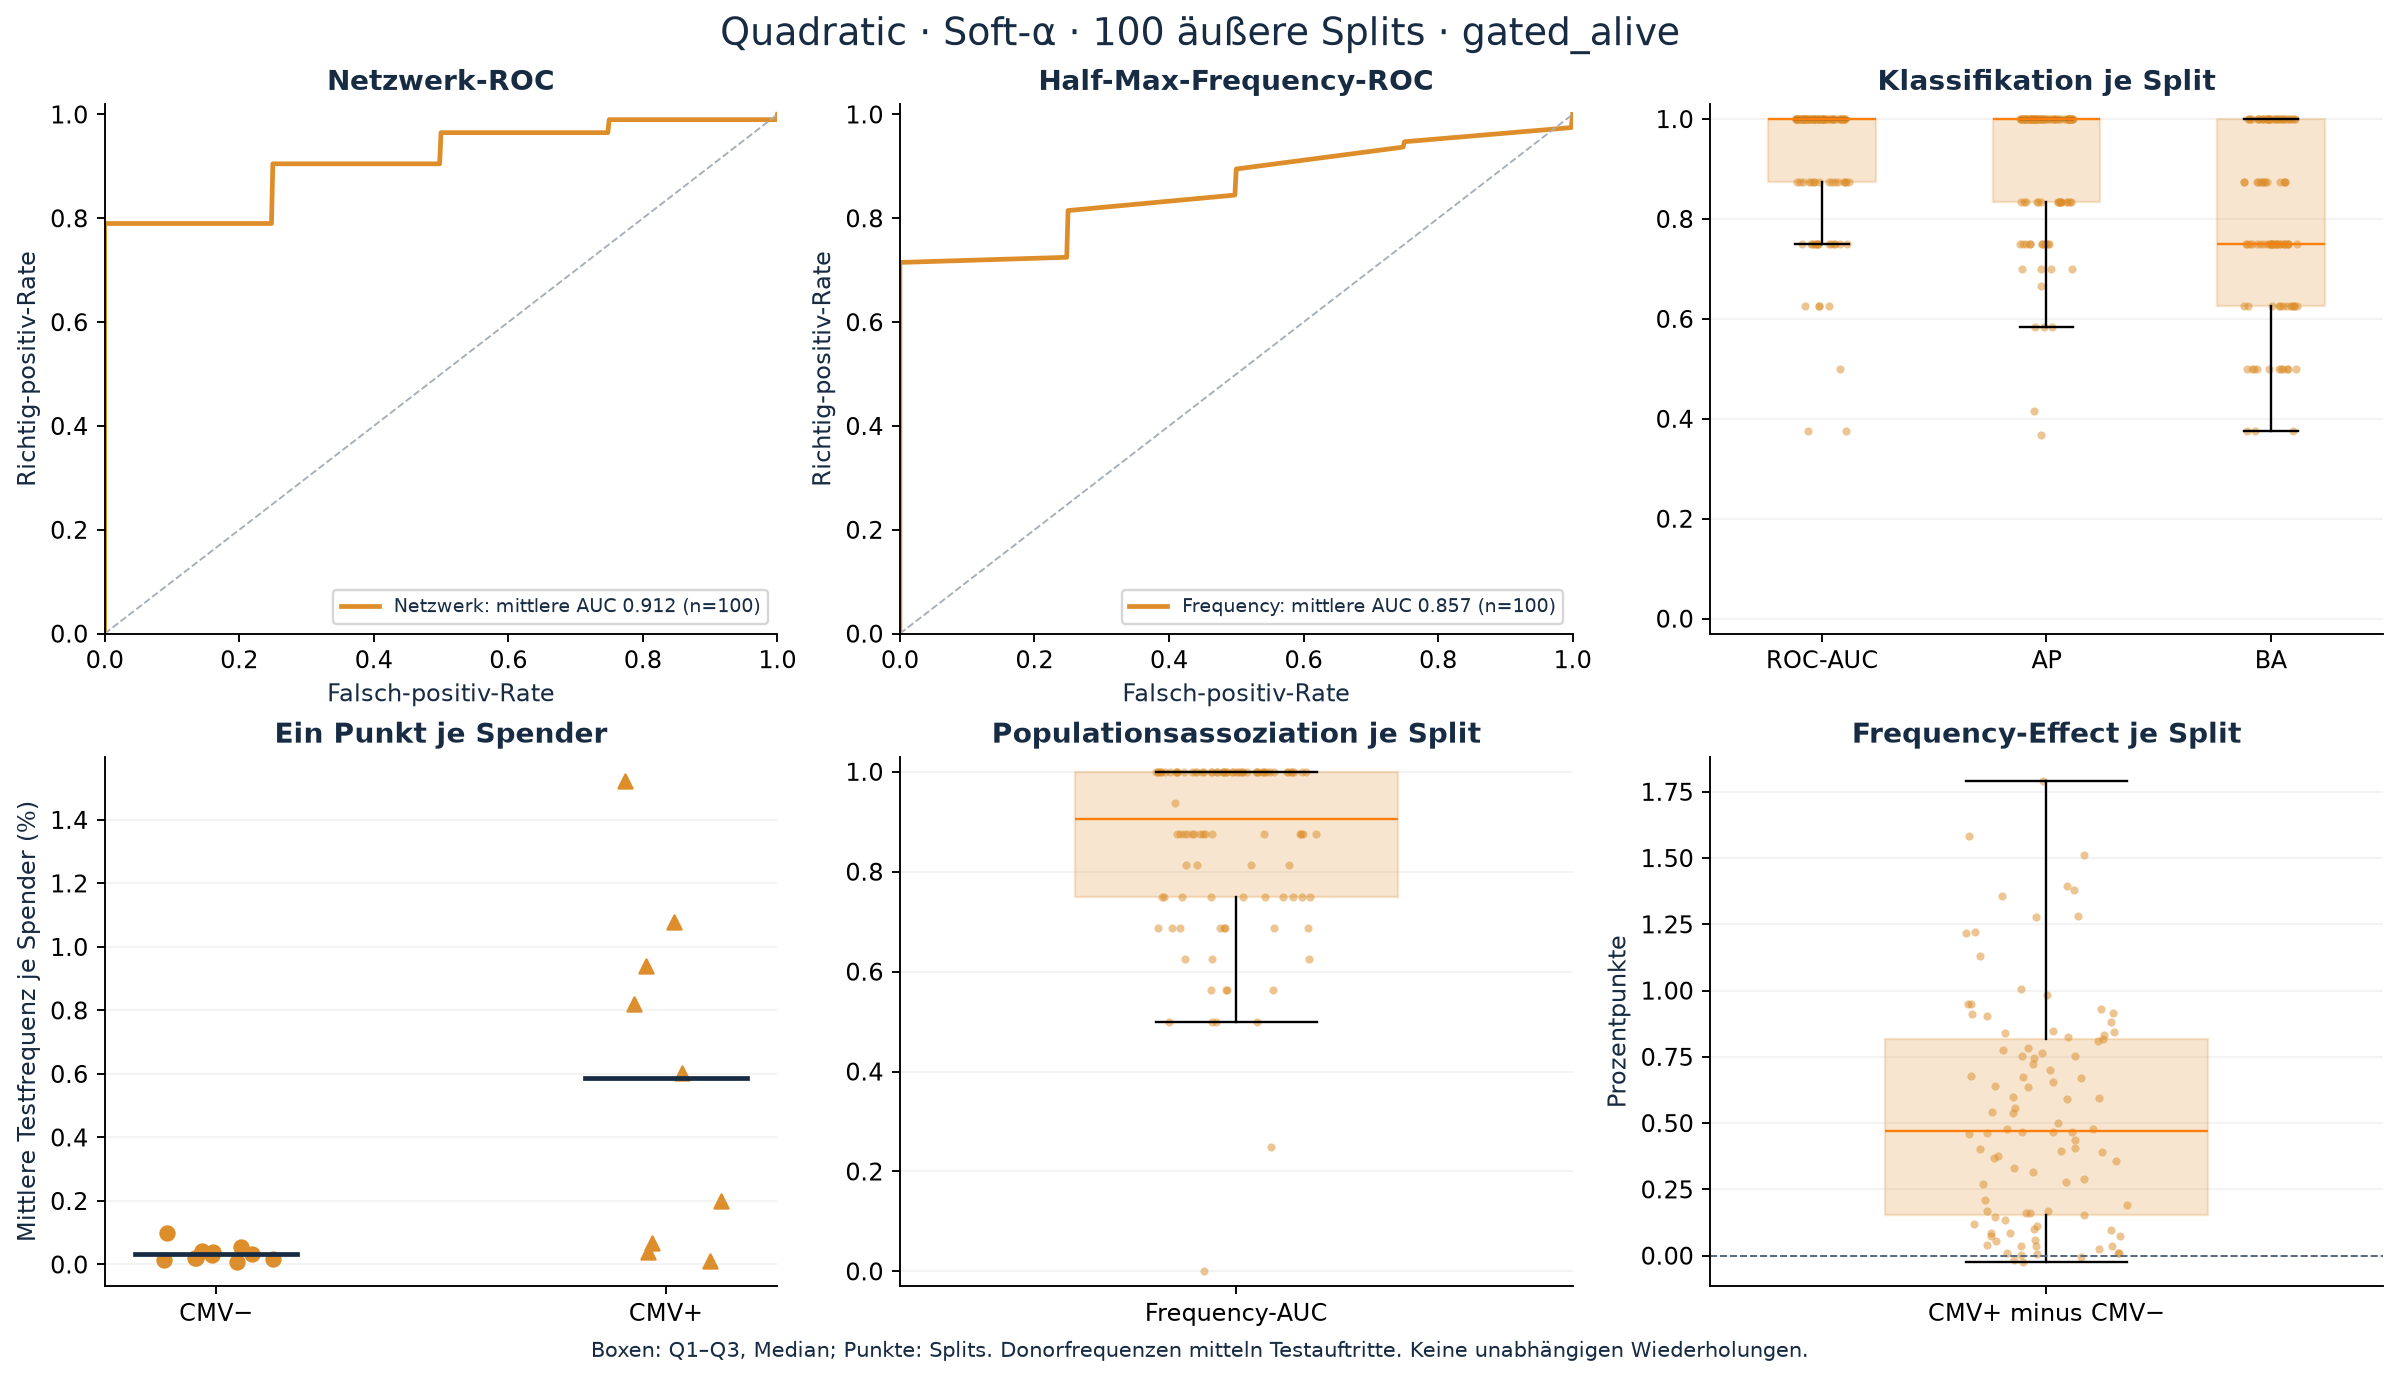

In [12]:
from src.task6_comparison import plot_model_results
from IPython.display import Image

plot_path = plot_model_results(modified_predictions, modified_frequencies, TABLES / "plots/quadratic_soft", "quadratic_soft", donor_splits)
display(Image(filename=str(plot_path)))
